<a href="https://colab.research.google.com/github/lianghuizi/Study/blob/main/CIFAR10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils import data
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import matplotlib.pyplot as plt
import numpy as np
import pickle

In [2]:
device=torch.device("cpu")
if torch.cuda.is_available():
  device=torch.device("cuda")
print(device)

cuda


In [3]:
IMAGE_SIZE=32

mean,std=[0.4914,0.4822,0.4465],[0.247,0.243,0.261]

composed_train=transforms.Compose([
    transforms.Resize((IMAGE_SIZE,IMAGE_SIZE)),
    transforms.RandomRotation(20),
    transforms.RandomHorizontalFlip(0.1),
    transforms.ColorJitter(brightness=0.1,contrast=0.1,saturation=0.1),
    transforms.RandomAdjustSharpness(sharpness_factor=2,p=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean,std),
    transforms.RandomErasing(p=0.75,scale=(0.02,0.1),value=1.0,inplace=False)
])

composed_test=transforms.Compose([
    transforms.Resize((IMAGE_SIZE,IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean,std)
    ])

In [4]:
train_dataset=datasets.CIFAR10(root="./data",train=True,download=True,transform=composed_train)
test_dataset=datasets.CIFAR10(root='./data',train=False,download=True,transform=composed_test)

print("train_dataset:",len(train_dataset))
print("test_dataset:",len(test_dataset))

100%|██████████| 170M/170M [00:13<00:00, 12.6MB/s]


train_dataset: 50000
test_dataset: 10000


In [5]:
train_loader=data.DataLoader(
    dataset=train_dataset,
    batch_size=100
    )
test_loader=data.DataLoader(
    dataset=test_dataset,
    batch_size=100
)

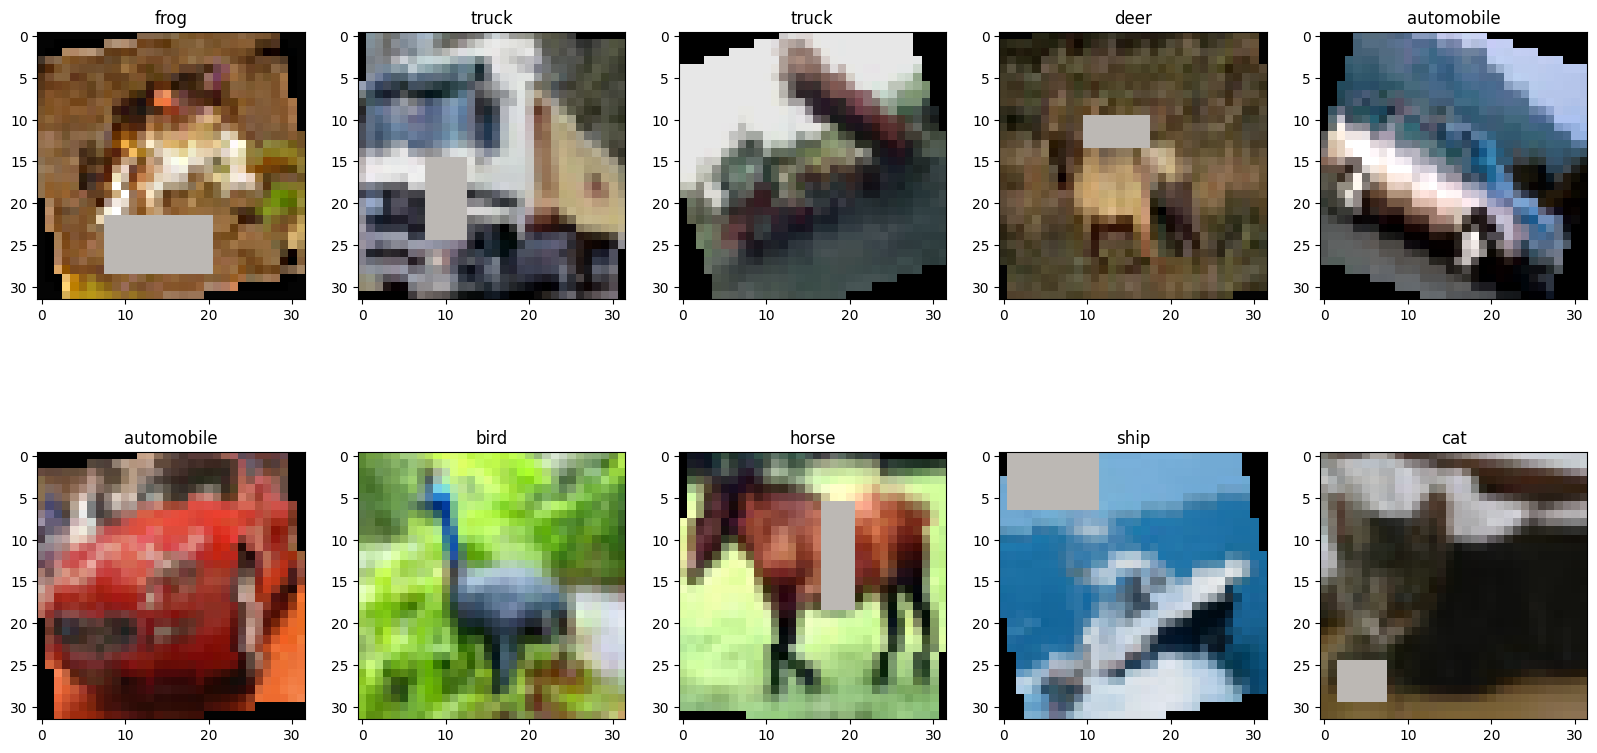

In [6]:
data_iterable=iter(train_loader)
images,labels=next(data_iterable)
images=images*torch.tensor(std).view(1,3,1,1)+torch.tensor(mean).view(1,3,1,1)
fig,axes=plt.subplots(2,5,figsize=(20,10))

for i in np.arange(10):
  row=i//5
  col=i%5

  img=images[i].detach().cpu().numpy().transpose(1,2,0)
  axes[row,col].imshow(img)
  axes[row,col].set_title(train_dataset.classes[labels[i].item()])

In [7]:
# (1)Define common model training module
def train_model(model,train_loader,test_loader,optimizer,epochs=20):
  N_test=len(test_dataset)
  accuracy_list=[]
  train_loss_list=[]
  model=model.to(device)
  train_cost_list=[]
  test_cost_list=[]

  for epoch in range(epochs):
    train_Cost=0
    for x,y in train_loader:
      x=x.to(device)
      y=y.to(device)
      model.train()
      optimizer.zero_grad()
      z=model(x)
      loss=criterion(z,y)
      loss.backward()
      optimizer.step()
      train_Cost+=loss.item()

    train_Cost=train_Cost/len(train_loader)
    train_cost_list.append(train_Cost)
    correct=0

    test_Cost=0
    for x_test,y_test in test_loader:
      model.eval()
      x_test=x_test.to(device)
      y_test=y_test.to(device)
      z=model(x_test)
      test_loss=criterion(z,y_test)
      _,yhat=torch.max(z.data,1)
      correct+=(yhat==y_test).sum().item()
      test_Cost+=test_loss.item()

    test_Cost=test_Cost/len(test_loader)
    test_cost_list.append(test_Cost)

    accuracy=correct/N_test
    accuracy_list.append(accuracy)

    print("--> Epoch Number: {}".format(epoch+1),
          "| Training Loss: {}".format(round(train_Cost,4)),
          "| Test Loss: {}".format(round(test_Cost,4)),
          "| Test Accuracy: {}".format(round(accuracy*100,2))
          )
  return accuracy_list,train_cost_list,test_cost_list

In [19]:
#（2）CNN Model V1：
# 1. 2 convolution + max pool layers
# 2. 2 fully connected layers
# 3. Default runtime using 0 momentum and 0 dropout value
class CNN(nn.Module):

  def __init__(self,out_1=32,out_2=64,number_of_classes=10):
    super(CNN,self).__init__()
    self.cnn1=nn.Conv2d(3,out_1,3,padding=1)
    self.cnn2=nn.Conv2d(out_1,out_2,3,padding=1)
    self.maxpool=nn.MaxPool2d(2)
    self.fc1=nn.Linear(out_2*8*8,1000)
    self.fc2=nn.Linear(1000,number_of_classes)
    self.relu=nn.ReLU()

  def forward(self,x):
    x=self.maxpool(self.relu(self.cnn1(x)))
    x=self.maxpool(self.relu(self.cnn2(x)))
    x=x.view(x.size(0),-1)
    x=self.relu(self.fc1(x))
    x=self.fc2(x)
    return x

In [20]:
model=CNN()
criterion=nn.CrossEntropyLoss()
learning_rate=0.1
optimizer=torch.optim.SGD(model.parameters(),lr=learning_rate)

In [21]:
accuracy_list_normal,train_cost_list,test_cost_list=train_model(model,train_loader,test_loader,optimizer)

--> Epoch Number: 1 | Training Loss: 1.6901 | Test Loss: 1.347 | Test Accuracy: 52.45
--> Epoch Number: 2 | Training Loss: 1.354 | Test Loss: 1.152 | Test Accuracy: 58.94
--> Epoch Number: 3 | Training Loss: 1.1931 | Test Loss: 1.0538 | Test Accuracy: 63.11
--> Epoch Number: 4 | Training Loss: 1.0792 | Test Loss: 0.9542 | Test Accuracy: 66.82
--> Epoch Number: 5 | Training Loss: 0.9929 | Test Loss: 0.8953 | Test Accuracy: 68.56
--> Epoch Number: 6 | Training Loss: 0.9207 | Test Loss: 0.8618 | Test Accuracy: 69.79
--> Epoch Number: 7 | Training Loss: 0.8538 | Test Loss: 0.8216 | Test Accuracy: 71.43
--> Epoch Number: 8 | Training Loss: 0.7937 | Test Loss: 0.8001 | Test Accuracy: 72.67
--> Epoch Number: 9 | Training Loss: 0.7485 | Test Loss: 0.8233 | Test Accuracy: 72.06
--> Epoch Number: 10 | Training Loss: 0.6936 | Test Loss: 0.7809 | Test Accuracy: 73.27
--> Epoch Number: 11 | Training Loss: 0.6517 | Test Loss: 0.7998 | Test Accuracy: 73.28
--> Epoch Number: 12 | Training Loss: 0.6127

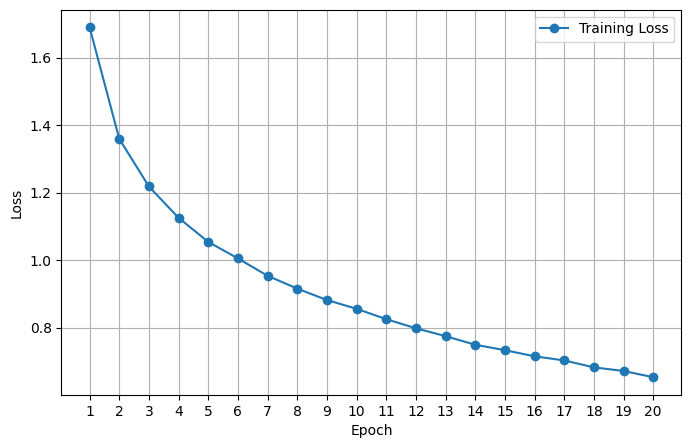

In [35]:
epochs_list=range(1,len(train_cost_list)+1)

plt.figure(figsize=(8,5))
plt.plot(epochs_list,train_cost_list,marker='o',label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel("Loss")
plt.xticks(epochs_list)
plt.grid(True)
plt.legend()
plt.show()

In [13]:
import os
os.makedirs("./model",exist_ok=True)
# Save model:
pickle.dump(model, open('./model/CNN_momentum_V1.pkl', 'wb'))

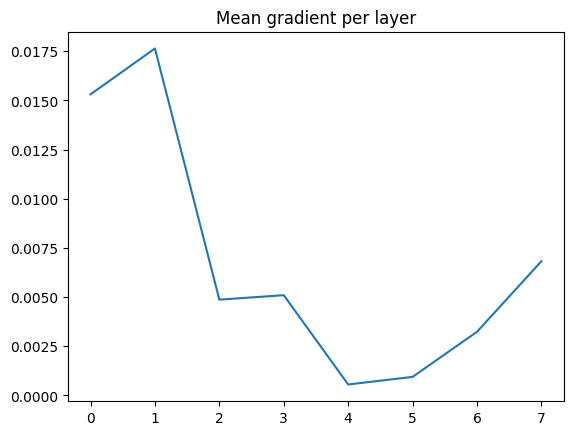

In [24]:
grads=[]
for p in model.parameters():
  if p.grad is not None:
    grads.append(p.grad.abs().mean().item())

plt.plot(grads)
plt.title("Mean gradient per layer")
plt.show()


In [22]:
#(3) CNN Model V2
# 1. 2 convolution & max pool layers
# 2. 2 fully connected layers
# 3. Default runtime using 0.2 momentum and dropout value p = 0.5
class CNN2(nn.Module):
  def __init__(self,out_1=32,out_2=64,num_of_classes=10,p=0):
    super(CNN2,self).__init__()
    self.cnn1=nn.Conv2d(3,out_1,3,padding=1)
    self.cnn2=nn.Conv2d(out_1,out_2,3,padding=1)
    self.maxpool=nn.MaxPool2d(2)
    self.fc1=nn.Linear(out_2*8*8,1000)
    self.drop=nn.Dropout(p)
    self.fc2=nn.Linear(1000,num_of_classes)
    self.relu=nn.ReLU()

  def forward(self,x):
    x=self.maxpool(self.relu(self.cnn1(x)))
    x=self.maxpool(self.relu(self.cnn2(x)))
    x=x.view(x.size(0),-1)
    x=self.drop(self.relu(self.fc1(x)))
    x=self.fc2(x)

    return x

In [23]:
# Define the model
model_mmtv2=CNN2(p=0.5)

# Define model learning hyperparameters
criterion=nn.CrossEntropyLoss()
learning_rate=0.1
optimizer=optim.SGD(model_mmtv2.parameters(),lr=learning_rate,momentum=0.2)

accuracy_list_normal,train_cost_list,test_cost_list=train_model(model_mmtv2,train_loader,test_loader,optimizer)


--> Epoch Number: 1 | Training Loss: 1.6901 | Test Loss: 1.3164 | Test Accuracy: 52.76
--> Epoch Number: 2 | Training Loss: 1.3594 | Test Loss: 1.1123 | Test Accuracy: 60.82
--> Epoch Number: 3 | Training Loss: 1.2183 | Test Loss: 1.0043 | Test Accuracy: 64.02
--> Epoch Number: 4 | Training Loss: 1.1253 | Test Loss: 0.9632 | Test Accuracy: 65.8
--> Epoch Number: 5 | Training Loss: 1.0542 | Test Loss: 0.9019 | Test Accuracy: 68.3
--> Epoch Number: 6 | Training Loss: 1.0052 | Test Loss: 0.8421 | Test Accuracy: 70.61
--> Epoch Number: 7 | Training Loss: 0.9538 | Test Loss: 0.8312 | Test Accuracy: 70.92
--> Epoch Number: 8 | Training Loss: 0.9157 | Test Loss: 0.7851 | Test Accuracy: 72.67
--> Epoch Number: 9 | Training Loss: 0.882 | Test Loss: 0.8265 | Test Accuracy: 71.29
--> Epoch Number: 10 | Training Loss: 0.856 | Test Loss: 0.7579 | Test Accuracy: 73.74
--> Epoch Number: 11 | Training Loss: 0.8252 | Test Loss: 0.7485 | Test Accuracy: 73.83
--> Epoch Number: 12 | Training Loss: 0.7983 

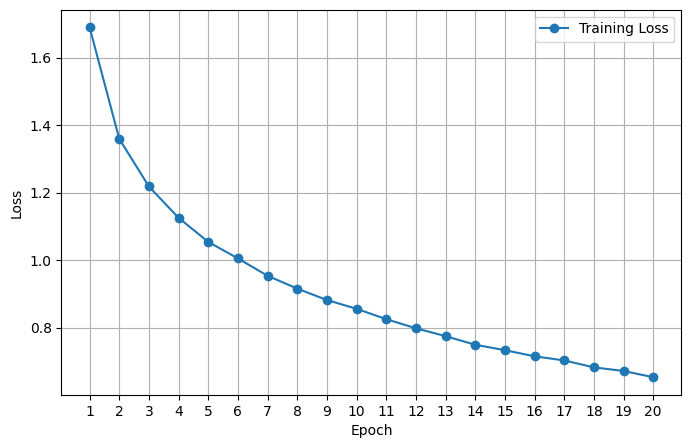

In [36]:
plt.figure(figsize=(8,5))
plt.plot(epochs_list,train_cost_list,marker='o',label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel("Loss")
plt.xticks(epochs_list)
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
torch.save(model_mmtv2.state_dict(),'./model/CNN_momentum_V2.pth')

In [13]:
#(3) CNN Model V3:
class CNN3(nn.Module):
  def __init__(self,out_1=32,out_2=64,num_of_classes=10,p=0):
    super(CNN3,self).__init__()
    self.cnn1=nn.Conv2d(3,out_1,3,padding=1)
    self.cnn2=nn.Conv2d(out_1,out_2,3,padding=1)
    self.maxpool=nn.MaxPool2d(2)
    self.fc1=nn.Linear(out_2*8*8,1000)
    self.fc2=nn.Linear(1000,512)
    self.fc3=nn.Linear(512,num_of_classes)
    self.drop=nn.Dropout(p)
    self.relu=nn.ReLU()

  def forward(self,x):
    x=self.maxpool(self.relu(self.cnn1(x)))
    x=self.maxpool(self.relu(self.cnn2(x)))
    x=x.view(x.size(0),-1)
    x=self.drop(self.relu(self.fc1(x)))
    x=self.drop(self.relu(self.fc2(x)))
    x=self.fc3(x)

    return x


In [14]:
model_mmtv3=CNN3(p=0.5)

criterion=nn.CrossEntropyLoss()
learning_rate=0.1
optimizer=optim.SGD(model_mmtv3.parameters(),momentum=0.2,lr=learning_rate)

accuracy_list_normal,train_cost_list,test_cost_list=train_model(model_mmtv3,train_loader,test_loader,optimizer)


--> Epoch Number: 1 | Training Loss: 1.8073 | Test Loss: 1.4215 | Test Accuracy: 48.91
--> Epoch Number: 2 | Training Loss: 1.4522 | Test Loss: 1.1901 | Test Accuracy: 57.08
--> Epoch Number: 3 | Training Loss: 1.2939 | Test Loss: 1.0391 | Test Accuracy: 63.18
--> Epoch Number: 4 | Training Loss: 1.1925 | Test Loss: 0.9933 | Test Accuracy: 65.02
--> Epoch Number: 5 | Training Loss: 1.117 | Test Loss: 0.8878 | Test Accuracy: 68.58
--> Epoch Number: 6 | Training Loss: 1.055 | Test Loss: 0.8736 | Test Accuracy: 69.67
--> Epoch Number: 7 | Training Loss: 1.004 | Test Loss: 0.8083 | Test Accuracy: 71.91
--> Epoch Number: 8 | Training Loss: 0.9655 | Test Loss: 0.7911 | Test Accuracy: 72.33
--> Epoch Number: 9 | Training Loss: 0.925 | Test Loss: 0.7639 | Test Accuracy: 73.53
--> Epoch Number: 10 | Training Loss: 0.8929 | Test Loss: 0.7429 | Test Accuracy: 74.33
--> Epoch Number: 11 | Training Loss: 0.8683 | Test Loss: 0.7207 | Test Accuracy: 74.97
--> Epoch Number: 12 | Training Loss: 0.8388 

In [18]:

class CNN4(nn.Module):
  def __init__(self,out_1=32,out_2=64,out_3=128,num_of_classes=10,p=0):
    super(CNN4,self).__init__()
    self.features=nn.Sequential(
        nn.Conv2d(3,out_1,3,padding=1),
        nn.BatchNorm2d(out_1),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Dropout2d(0.2),

        nn.Conv2d(out_1,out_2,3,padding=1),
        nn.BatchNorm2d(out_2),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Dropout2d(0.2),

        nn.Conv2d(out_2,out_3,3,padding=1),
        nn.BatchNorm2d(out_3),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Dropout2d(0.2),
    )

    self.classifier=nn.Sequential(
        nn.Linear(128*4*4,1000),
        nn.BatchNorm1d(1000),
        nn.ReLU(),
        nn.Dropout(p),

        nn.Linear(1000,512),
        nn.BatchNorm1d(512),
        nn.ReLU(),
        nn.Dropout(p),

        nn.Linear(512,10)
    )

  def forward(self,x):
     x=self.features(x)
     x=x.reshape(x.size(0),-1)
     x=self.classifier(x)
     return x

In [19]:
model4=CNN4(p=0.5)

criterion=nn.CrossEntropyLoss()
learning_rate=0.1
optimizer=optim.SGD(model4.parameters(),lr=learning_rate,momentum=0.2)

accuracy_list_normal,train_cost_list,test_cost_list=train_model(model4,train_loader,test_loader,optimizer)


--> Epoch Number: 1 | Training Loss: 1.8147 | Test Loss: 1.3657 | Test Accuracy: 49.18
--> Epoch Number: 2 | Training Loss: 1.5705 | Test Loss: 1.1983 | Test Accuracy: 56.08
--> Epoch Number: 3 | Training Loss: 1.4458 | Test Loss: 1.132 | Test Accuracy: 58.63
--> Epoch Number: 4 | Training Loss: 1.3713 | Test Loss: 1.0514 | Test Accuracy: 62.26
--> Epoch Number: 5 | Training Loss: 1.3162 | Test Loss: 1.0125 | Test Accuracy: 63.59
--> Epoch Number: 6 | Training Loss: 1.2698 | Test Loss: 0.9634 | Test Accuracy: 65.9
--> Epoch Number: 7 | Training Loss: 1.2336 | Test Loss: 0.949 | Test Accuracy: 66.8
--> Epoch Number: 8 | Training Loss: 1.1976 | Test Loss: 0.9067 | Test Accuracy: 68.08
--> Epoch Number: 9 | Training Loss: 1.1725 | Test Loss: 0.8811 | Test Accuracy: 69.04
--> Epoch Number: 10 | Training Loss: 1.1463 | Test Loss: 0.8431 | Test Accuracy: 70.51
--> Epoch Number: 11 | Training Loss: 1.1213 | Test Loss: 0.8179 | Test Accuracy: 71.14
--> Epoch Number: 12 | Training Loss: 1.1075 

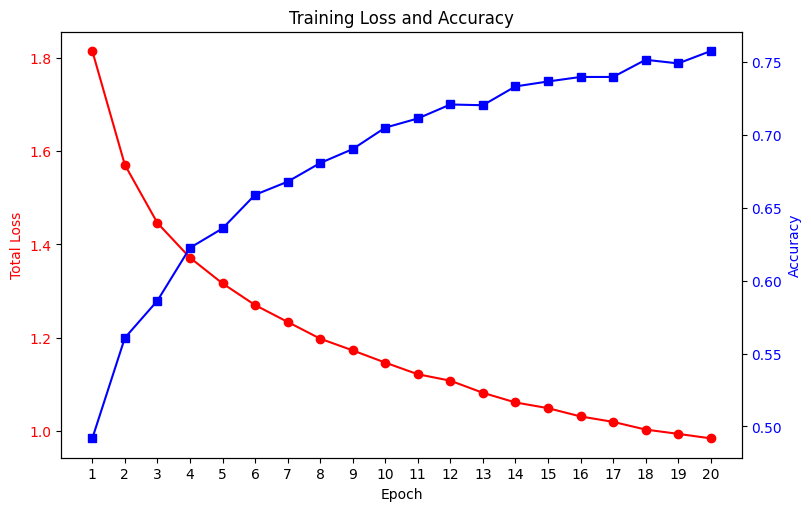

In [42]:
epochs = range(1, len(train_cost_list) + 1)

fig, ax1 = plt.subplots(figsize=(8, 5),constrained_layout=True)

# Loss
ax1.plot(epochs, train_cost_list,
         color='red',
         marker='o',
         label='Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Total Loss', color='red')
ax1.tick_params(axis='y', labelcolor='red')

# Accuracy
ax2 = ax1.twinx()
ax2.plot(epochs, accuracy_list_normal,
         color='blue',
         marker='s',
         label='Accuracy')
ax2.set_ylabel('Accuracy', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

plt.xticks(epochs)
plt.title('Training Loss and Accuracy')
plt.show()